# Proyecto 1 - Competencia de modelación
Abby Donis 22440

In [ ]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import joblib
import json
import os
from google.colab import drive
drive.mount('/content/drive')

archivo = "/content/drive/MyDrive/Colab_Notebooks/Proyecto1/train.csv"
var_obj = 'SalePrice'

MODEL_PATH = '/content/drive/MyDrive/Colab_Notebooks/Proyecto1'

df = pd.read_csv(archivo)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### EDA

In [ ]:
print("=== EXPLORACION INICIAL ===")
print(f"Dimensiones:\n - Filas: {df.shape[0]}\n - Columnas: {df.shape[1]}")

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.to_list()
cat_cols = df.select_dtypes(include=['object']).columns.to_list()
print(f"\nVariables numericas: {len(num_cols)}")
print(f"Variables categoricas: {len(cat_cols)}")
print(f"Variable objetivo: {var_obj}")

print(f"\nEstadisticas descriptivas:\n{df[num_cols].describe().round(2)}")

if var_obj in num_cols:
    num_cols.remove(var_obj)

#preprocesameinto
print("\n=== TRATAMIENTO DE DATOS ===")
#nuelos
print("\n--- VALORES NULOS ---")
null_counts = df.isnull().sum()
null_percent = ((null_counts/len(df))*100).round(2)
null_df = pd.DataFrame({
    'Nulos': null_counts,
    'Porcentaje': null_percent
}).sort_values('Nulos', ascending=False)

null_with_values = null_df[null_df['Nulos'] > 0]
if len(null_with_values) > 0:
    print(null_with_values)
else:
    print("No hay valores nulos")

#outilers
print("\n--- OUTLIERS --")
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return {
        'col': col,
        'lower': lower,
        'upper': upper,
        'n_outliers': len(outliers),
        'pct': len(outliers) / len(df) * 100
    }

outlier_count = 0
for col in num_cols[:10]:  #top 10
    info = detect_outliers_iqr(df, col)
    if info['n_outliers'] > 0:
        print(f"  {col}: {info['n_outliers']} outliers"
              f"\n  - Limites: [{info['lower']:.2f}, {info['upper']:.2f}]")
        outlier_count += 1

if outlier_count == 0:
    print("  No se detectaron outliers")

=== EXPLORACION INICIAL ===
Dimensiones:
 - Filas: 1168
 - Columnas: 81

Variables numericas: 38
Variables categoricas: 43
Variable objetivo: SalePrice

Estadisticas descriptivas:
            Id  MSSubClass  LotFrontage    LotArea  OverallQual  OverallCond  \
count  1168.00     1168.00       951.00    1168.00      1168.00      1168.00   
mean    730.90       56.85        70.34   10689.64         6.12         5.58   
std     425.37       42.53        24.90   10759.37         1.37         1.12   
min       1.00       20.00        21.00    1300.00         1.00         1.00   
25%     360.75       20.00        59.00    7587.25         5.00         5.00   
50%     732.50       50.00        70.00    9600.00         6.00         5.00   
75%    1101.75       70.00        80.00   11700.00         7.00         6.00   
max    1460.00      190.00       313.00  215245.00        10.00         9.00   

       YearBuilt  YearRemodAdd  MasVnrArea  BsmtFinSF1  ...  WoodDeckSF  \
count    1168.00       1

=== VISUALIZACIONES ===


/tmp/ipykernel_1025/3525022346.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=top_cats, vert=True)


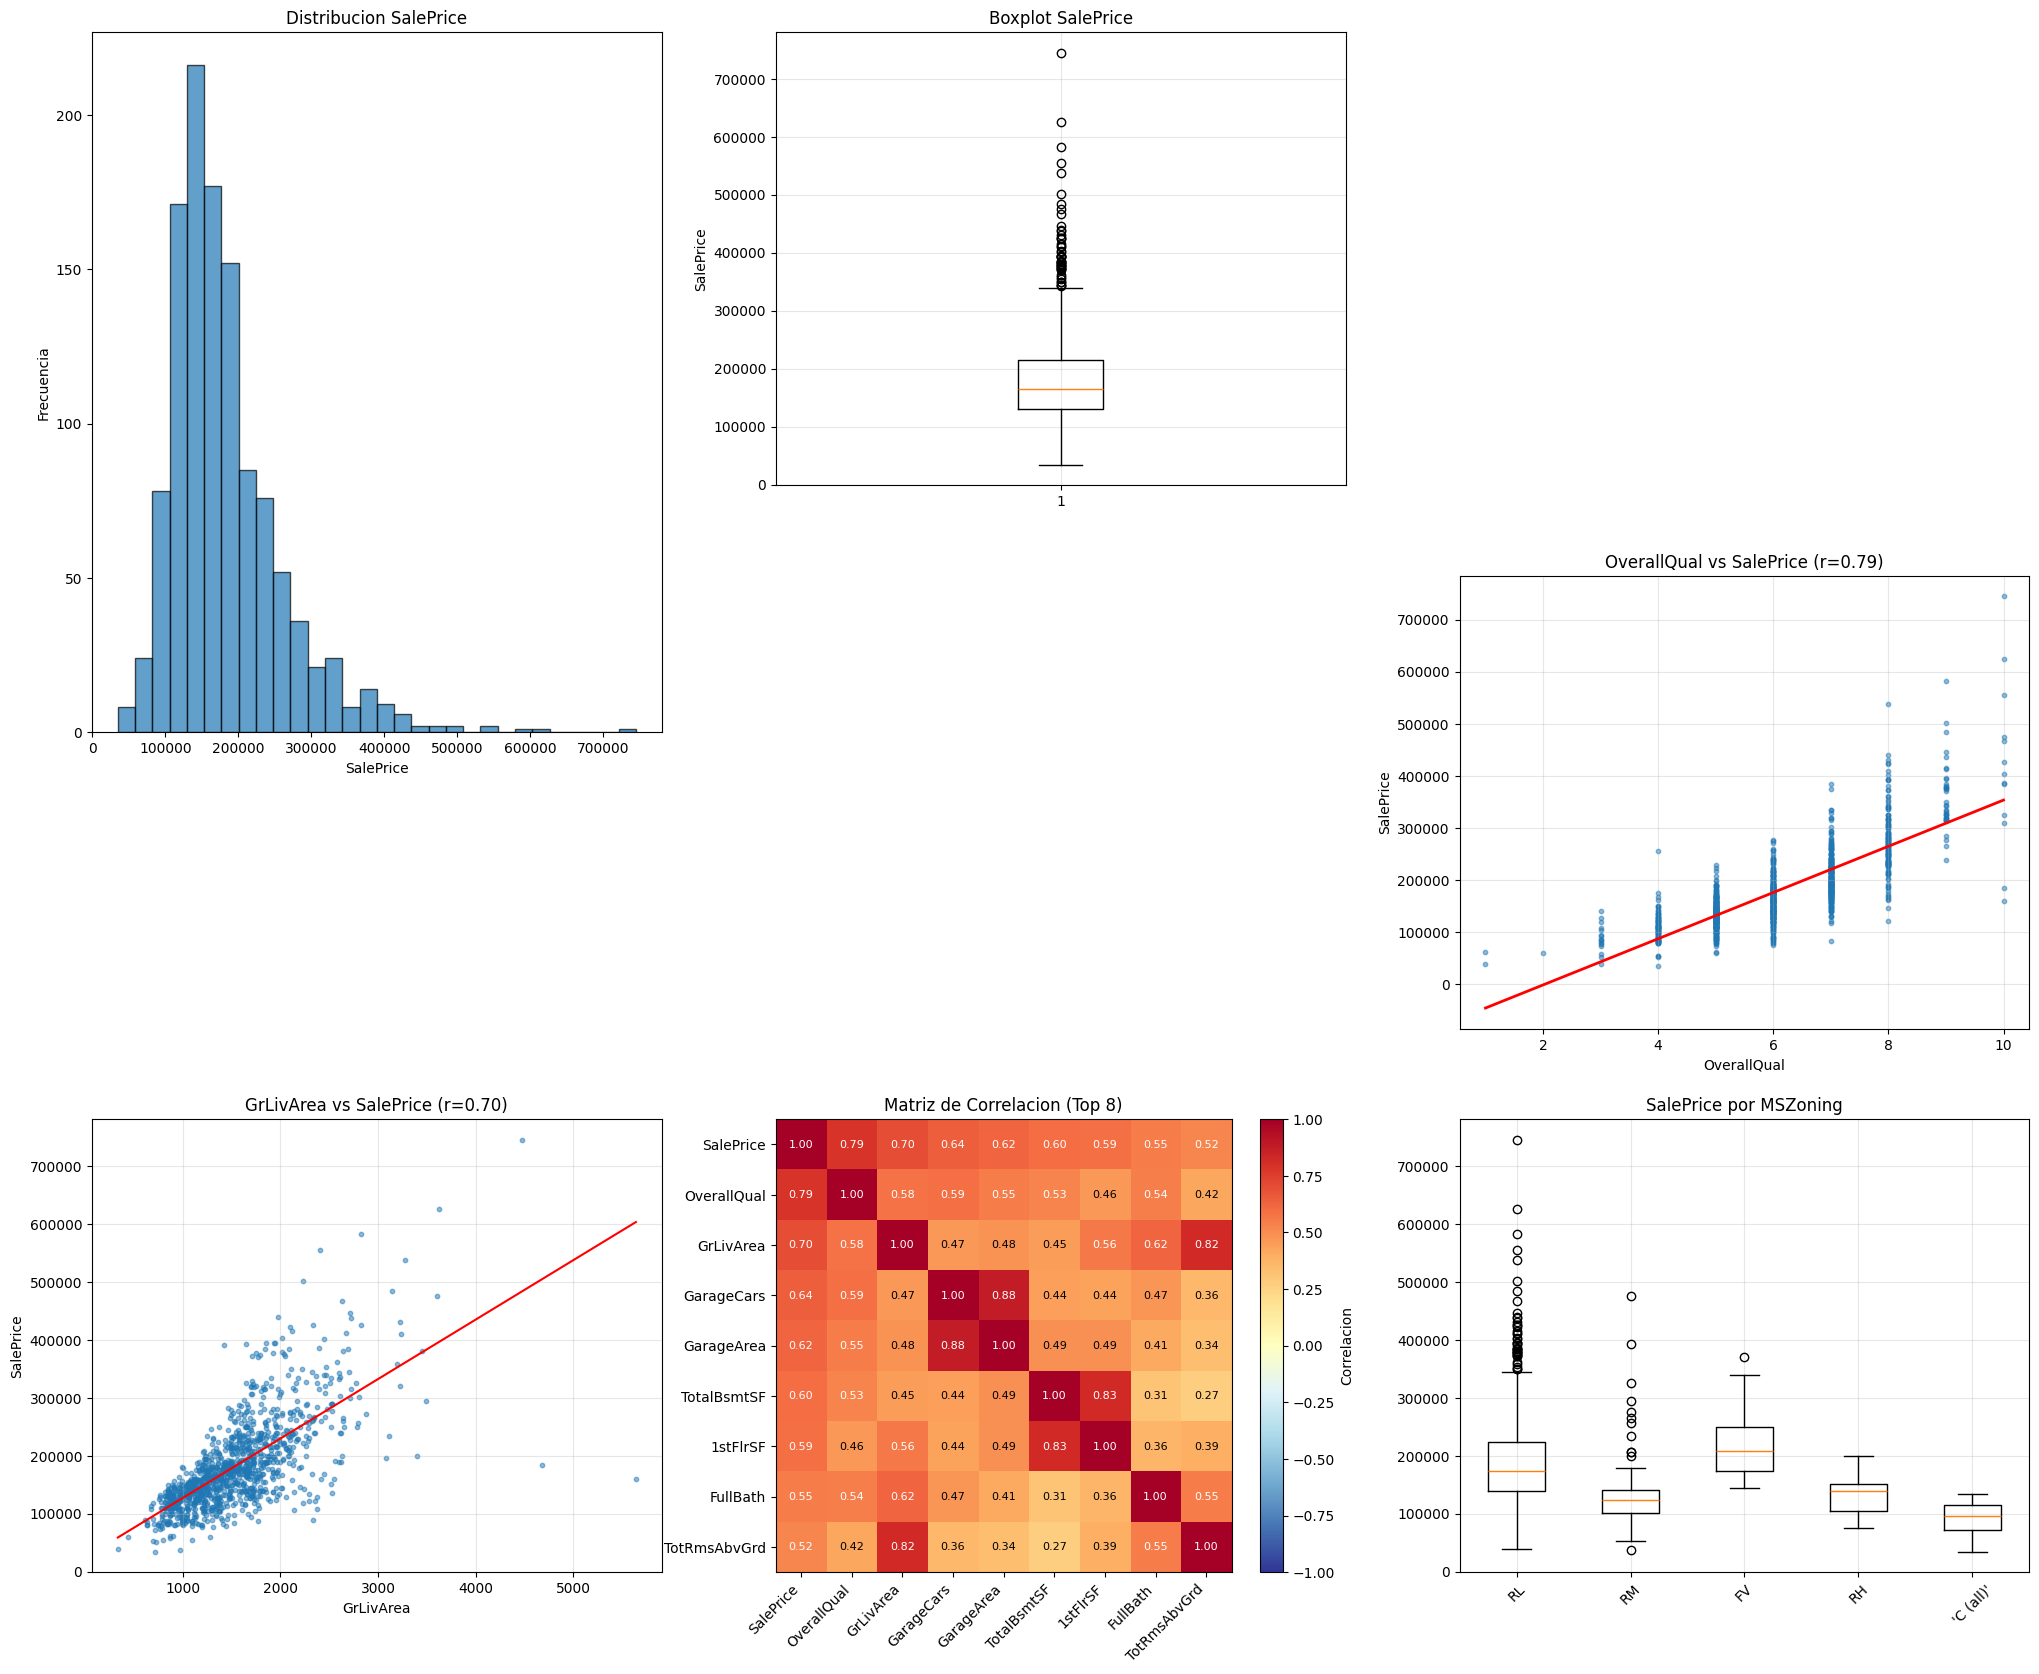

In [ ]:
print("=== VISUALIZACIONES ===")

plt.style.use('default')
fig = plt.figure(figsize=(25, 20))

#hist var_obj
plt.subplot(2, 3, 1)
plt.hist(df[var_obj], bins=30, edgecolor='black', alpha=0.7)
plt.title(f'Distribucion {var_obj}')
plt.xlabel(var_obj)
plt.ylabel('Frecuencia')

#boxplot var_obj
plt.subplot(3, 3, 2)
plt.boxplot(df[var_obj].dropna(), vert=True)
plt.title(f'Boxplot {var_obj}')
plt.ylabel(var_obj)
plt.grid(True, alpha=0.3)

#correacion
if len(num_cols) > 1:
    correlations = df[num_cols + [var_obj]].corr()[var_obj].sort_values(ascending=False)
    top_var = correlations.index[1]

    plt.subplot(3, 3, 6)
    plt.scatter(df[top_var], df[var_obj], alpha=0.5, s=10)
    plt.xlabel(top_var)
    plt.ylabel(var_obj)
    plt.title(f'{top_var} vs {var_obj} (r={correlations[top_var]:.2f})')
    #linea tendencia
    z = np.polyfit(df[top_var], df[var_obj], 1)
    p = np.poly1d(z)
    x_line = np.sort(df[top_var])
    plt.plot(x_line, p(x_line), "r-", linewidth=2)
    plt.grid(True, alpha=0.3)

#2da on correlaicon
if len(num_cols) > 2:
    second_var = correlations.index[2]
    plt.subplot(3, 3, 7)
    plt.scatter(df[second_var], df[var_obj], alpha=0.5, s=10)
    plt.xlabel(second_var)
    plt.ylabel(var_obj)
    plt.title(f'{second_var} vs {var_obj} (r={correlations[second_var]:.2f})')
    z = np.polyfit(df[second_var], df[var_obj], 1)
    p = np.poly1d(z)
    x_line = np.sort(df[second_var])
    plt.plot(x_line, p(x_line), "r-")
    plt.grid(True, alpha=0.3)

#heamap
plt.subplot(3, 3, 8)
#top 8
top_corr_vars = correlations.index[:9].tolist()
corr_matrix = df[top_corr_vars].corr().values
corr_labels = top_corr_vars

im = plt.imshow(corr_matrix, cmap='RdYlBu_r', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(im, label='Correlacion')
plt.xticks(range(len(corr_labels)), corr_labels, rotation=45, ha='right')
plt.yticks(range(len(corr_labels)), corr_labels)
plt.title('Matriz de Correlacion (Top 8)')

for i in range(len(corr_labels)):
    for j in range(len(corr_labels)):
        plt.text(j, i, f'{corr_matrix[i, j]:.2f}',
                ha='center', va='center',
                color='white' if abs(corr_matrix[i, j]) > 0.5 else 'black',
                fontsize=8)

#boxplota con cat
if len(cat_cols) > 0:
    plt.subplot(3, 3, 9)
    cat_col = cat_cols[0]
    top_cats = df[cat_col].value_counts().head(5).index
    data_to_plot = [df[df[cat_col] == cat][var_obj].values for cat in top_cats]
    plt.boxplot(data_to_plot, labels=top_cats, vert=True)
    plt.title(f'{var_obj} por {cat_col}')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)

plt.show()

## Entrenamiento

In [ ]:
print("=== ENTRENAMIENTO ===")

def preprocess_data(df, target_col, scaler=None, fit_scalers=True):
    df_clean = df.copy()

    #+30% nulos, eliminar
    null_pct = df_clean.isnull().mean() * 100
    cols_to_drop = null_pct[null_pct > 30].index.tolist()
    df_clean = df_clean.drop(columns=cols_to_drop)
    print(f"Columnas eliminadas por >30% nulos: {cols_to_drop}")

    #transformacion cat
    cat_cols = df_clean.select_dtypes(include=['object']).columns
    for col in cat_cols:
        if df_clean[col].isnull().any():
            df_clean[col] = df_clean[col].fillna('NA')
            print(f"  Rellenados nulos en {col} con 'NA'")

    #transaofrmacion num, mediana
    num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
    num_cols = [col for col in num_cols if col != target_col]
    for col in num_cols:
        if df_clean[col].isnull().any():
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
            print(f"  Rranformacion de datos a mediana")

    print("\nVerificando inconsistencias...")
    if (df_clean[target_col] <= 0).any():
        neg_count = (df_clean[target_col] <= 0).sum()
        print(f"    {neg_count} registros con {target_col} <= 0 (eliminados)")
        df_clean = df_clean[df_clean[target_col] > 0]

    #1800-2026
    year_cols = [col for col in num_cols if 'Year' in col or 'Yr' in col]
    for col in year_cols:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].clip(lower=1800, upper=2026)
            print(f"  Corregidos años en {col} (1800-2026)")

    #winsoriz
    print("\nWinsorizando outliers...")
    for col in num_cols:
        lower = df_clean[col].quantile(0.01)
        upper = df_clean[col].quantile(0.99)
        df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
        print(f"  - {col} winsorizada")

    #onehot enconder
    print("\nCodificando variables categoricas...")
    cat_cols_final = df_clean.select_dtypes(include=['object']).columns.tolist()
    if cat_cols_final:
        original_cat_cols = cat_cols_final.copy()
        df_clean = pd.get_dummies(df_clean, columns=cat_cols_final, drop_first=True)
        print(f"  One-Hot Encoding aplicado a: {original_cat_cols}")

    X = df_clean.drop(target_col, axis=1)
    y = df_clean[target_col]

    if fit_scalers:
        scaler_X = RobustScaler()
        X_scaled = scaler_X.fit_transform(X)
        print(f"\nScaler ajustado con {X.shape[1]} caracteristicas")

        scaler_y = RobustScaler()
        y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1)).flatten()
        print(f"Scaler de {var_obj} ajustado")
        print(f"\t Original:\n\t - Media: {y.mean():.2f}\n\t - Std: {y.std():.2f}")
        print(f"\t Escalado: \n\t - Media: {y_scaled.mean():.2f}\n\t - Std: {y_scaled.std():.2f}")
    else:
        X_scaled = scaler_X.transform(X)
        y_scaled = scaler_y.transform(y.values.reshape(-1,1)).flatten()
        print(f"\nScalers aplicados")

    feature_names = X.columns.tolist()

    return X_scaled, y_scaled, scaler_X, scaler_y, feature_names

X_scaled, y_scaled, scaler_X, scaler_y, feature_names = preprocess_data(df, var_obj)

#division
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"\nDivision dataset:")
print(f"  - Entrenamiento: {len(X_train)} muestras")
print(f"  - Validacion: {len(X_val)} muestras")
print(f"  - Prueba: {len(X_test)} muestras")

#tensores
X_train_tensor = torch.FloatTensor(X_train)
X_val_tensor = torch.FloatTensor(X_val)
X_test_tensor = torch.FloatTensor(X_test)

y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
y_val_tensor = torch.FloatTensor(y_val).reshape(-1, 1)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)

#dataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

=== ENTRENAMIENTO ===
Columnas eliminadas por >30% nulos: ['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']
  Rellenados nulos en BsmtQual con 'NA'
  Rellenados nulos en BsmtCond con 'NA'
  Rellenados nulos en BsmtExposure con 'NA'
  Rellenados nulos en BsmtFinType1 con 'NA'
  Rellenados nulos en BsmtFinType2 con 'NA'
  Rellenados nulos en Electrical con 'NA'
  Rellenados nulos en GarageType con 'NA'
  Rellenados nulos en GarageFinish con 'NA'
  Rellenados nulos en GarageQual con 'NA'
  Rellenados nulos en GarageCond con 'NA'
  Rranformacion de datos a mediana
  Rranformacion de datos a mediana
  Rranformacion de datos a mediana

Verificando inconsistencias...
  Corregidos años en YearBuilt (1800-2026)
  Corregidos años en YearRemodAdd (1800-2026)
  Corregidos años en GarageYrBlt (1800-2026)
  Corregidos años en YrSold (1800-2026)

Winsorizando outliers...
  - Id winsorizada
  - MSSubClass winsorizada
  - LotFrontage winsorizada
  - LotArea winsorizada
  - Overal

## MLP

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, activation='relu', dropout=0.0):
        super(MLP, self).__init__()
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))

            if activation == 'relu':
                layers.append(nn.ReLU())
            elif activation == 'leaky_relu':
                layers.append(nn.LeakyReLU(0.1))
            elif activation == 'selu':
                layers.append(nn.SELU())
            elif activation == 'tanh':
                layers.append(nn.Tanh())
            elif activation == 'sigmoid':
                layers.append(nn.Sigmoid())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

def train_model(model, train_loader, val_loader, optimizer, criterion, epochs, device, early_stopping_patience=20):
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        #traingin
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        #val
        if val_loader is not None:
          model.eval()
          val_loss = 0.0
          with torch.no_grad():
              for X_batch, y_batch in val_loader:
                  X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                  outputs = model(X_batch)
                  loss = criterion(outputs, y_batch)
                  val_loss += loss.item() * X_batch.size(0)
          val_loss /= len(val_loader.dataset)
          val_losses.append(val_loss)

          #early stp
          if val_loss < best_val_loss:
              best_val_loss = val_loss
              patience_counter = 0
          else:
              patience_counter += 1
              if patience_counter >= early_stopping_patience:
                  print(f"Early stopping en epoch {epoch+1}")
                  break

          if (epoch + 1) % 20 == 0:
              print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.2f}, Val Loss: {val_loss:.2f}')
        else:
          if (epoch + 1) % 20 == 0:
                print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.2f}')


    return train_losses, val_losses

def evaluate_model(model, X_tensor, y_tensor, scaler_y, device):
    model.eval()
    with torch.no_grad():
        X_tensor = X_tensor.to(device)
        predictions_scaled = model(X_tensor).cpu().numpy()
        y_true_scaled = y_tensor.numpy()

    predictions = scaler_y.inverse_transform(predictions_scaled)
    y_true = scaler_y.inverse_transform(y_true_scaled)

    rmse = np.sqrt(mean_squared_error(y_true, predictions))
    mae = mean_absolute_error(y_true, predictions)
    r2 = r2_score(y_true, predictions)

    return {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'predictions': predictions,
        'predictions_scaled': predictions_scaled
    }

### Iteracines modelos

In [ ]:
print("=== ITERACIONES MLP ===")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Dispositivo: {device}")

#configs
config = [
    {
        'name': 'Base',
        'hidden_layers': [64, 32],
        'activation': 'relu',
        'lr': 0.001,
        'dropout': 0.0,
        'weight_decay': 0.0,
        'batch_size': 64,
        'epochs': 250
    },
    {
        'name': 'Arquitectura + Profunda',
        'hidden_layers': [128, 64, 32],
        'activation': 'relu',
        'lr': 0.001,
        'dropout': 0.0,
        'weight_decay': 0.0,
        'batch_size': 64,
        'epochs': 250
    },
    {
        'name': 'LeakyReLU',
        'hidden_layers': [64, 32],
        'activation': 'leaky_relu',
        'lr': 0.001,
        'dropout': 0.0,
        'weight_decay': 0.0,
        'batch_size': 64,
        'epochs': 250
    },
    {
        'name': 'Dropout 0.2',
        'hidden_layers': [64, 32],
        'activation': 'relu',
        'lr': 0.001,
        'dropout': 0.25,
        'weight_decay': 0.0,
        'batch_size': 64,
        'epochs': 250
    },
    {
        'name': 'Weight Decay 0.001',
        'hidden_layers': [64, 32],
        'activation': 'relu',
        'lr': 0.001,
        'dropout': 0.0,
        'weight_decay': 0.0005,
        'batch_size': 64,
        'epochs': 250
    },
    {
        'name': 'Dropout + Weight Decay',
        'hidden_layers': [64, 32],
        'activation': 'relu',
        'lr': 0.0005,
        'dropout': 0.25,
        'weight_decay': 0.0005,
        'batch_size': 32,
        'epochs': 250
    },
    {
        'name': 'Arquitectura Final',
        'hidden_layers': [128, 64, 32, 16],
        'activation': 'leaky_relu',
        'lr': 0.0005,
        'dropout': 0.25,
        'weight_decay': 0.0005,
        'batch_size': 32,
        'epochs': 300
    }
]

results = []
best_rmse = float('inf')
best_model = None
best_config = None

for idx, config in enumerate(config, 1):
    print(f"\n--- Experimento {idx}: {config['name']} ---")
    print(f"Configuración: {config}")

    #modleo creare
    model = MLP(
        input_dim=X_train_tensor.shape[1],
        hidden_layers=config['hidden_layers'],
        activation=config['activation'],
        dropout=config['dropout']
    ).to(device)

    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)

    optimizer = optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    criterion = nn.MSELoss()

    train_losses, val_losses = train_model(
        model, train_loader, val_loader, optimizer, criterion,
        config['epochs'], device
    )

    val_metrics = evaluate_model(model, X_val_tensor, y_val_tensor, scaler_y, device)

    print(f"  RMSE Validacion: {val_metrics['RMSE']:.2f}")

    results.append({
        'iteration': idx,
        'name': config['name'],
        'config': config,
        'val_metrics': val_metrics,
        'train_losses': train_losses,
        'val_losses': val_losses
    })

    #mejor modelo
    if val_metrics['RMSE'] < best_rmse:
        best_rmse = val_metrics['RMSE']
        best_model = model
        best_config = config
        best_train_losses = train_losses
        best_val_losses = val_losses

        torch.save(model.state_dict(), f'{MODEL_PATH}/best_model_checkpoint.pth')
        print(f"\nNuevo mejor modelo con RMSE: {best_rmse:.2f}")

    del model, optimizer, train_loader, val_loader
    torch.cuda.empty_cache()

print("\n--- RESULTADOS ---")
results_df = pd.DataFrame([
    {
        'Iter': r['iteration'],
        'Nombre': r['name'],
        'Arquitectura': str(r['config']['hidden_layers']),
        'Activación': r['config']['activation'],
        'Dropout': r['config']['dropout'],
        'Weight Decay': r['config']['weight_decay'],
        'LR': r['config']['lr'],
        'Batch Size': r['config']['batch_size'],
        'RMSE Val': r['val_metrics']['RMSE'],
        'MAE Val': r['val_metrics']['MAE'],
        'R2 Val': r['val_metrics']['R2']
    }
    for r in results
])
print(results_df.to_string(index=False))

=== ITERACIONES MLP ===
Dispositivo: cpu

--- Experimento 1: Base ---
Configuración: {'name': 'Base', 'hidden_layers': [64, 32], 'activation': 'relu', 'lr': 0.001, 'dropout': 0.0, 'weight_decay': 0.0, 'batch_size': 64, 'epochs': 300}
Epoch 20/300, Train Loss: 0.10, Val Loss: 0.16
Epoch 40/300, Train Loss: 0.07, Val Loss: 0.15
Early stopping en epoch 59
  RMSE Validacion: 35745.72

Nuevo mejor modelo con RMSE: 35745.72

--- Experimento 2: Arquitectura + Profunda ---
Configuración: {'name': 'Arquitectura + Profunda', 'hidden_layers': [128, 64, 32], 'activation': 'relu', 'lr': 0.001, 'dropout': 0.0, 'weight_decay': 0.0, 'batch_size': 64, 'epochs': 300}
Epoch 20/300, Train Loss: 0.08, Val Loss: 0.22
Early stopping en epoch 37
  RMSE Validacion: 34541.72

Nuevo mejor modelo con RMSE: 34541.72

--- Experimento 3: LeakyReLU ---
Configuración: {'name': 'LeakyReLU', 'hidden_layers': [64, 32], 'activation': 'leaky_relu', 'lr': 0.001, 'dropout': 0.0, 'weight_decay': 0.0, 'batch_size': 64, 'epochs

# Modelo final

=== ENTRENAMIENTO MODELO FINAL ===
Epoch 20/300, Train Loss: 0.22
Epoch 40/300, Train Loss: 0.16
Epoch 60/300, Train Loss: 0.14
Epoch 80/300, Train Loss: 0.12
Epoch 100/300, Train Loss: 0.14
Epoch 120/300, Train Loss: 0.12
Epoch 140/300, Train Loss: 0.11
Epoch 160/300, Train Loss: 0.11
Epoch 180/300, Train Loss: 0.11
Epoch 200/300, Train Loss: 0.09
Epoch 220/300, Train Loss: 0.10
Epoch 240/300, Train Loss: 0.08
Epoch 260/300, Train Loss: 0.09
Epoch 280/300, Train Loss: 0.09
Epoch 300/300, Train Loss: 0.08
--- RESULTADOS ---
  RMSE: 26,061.84


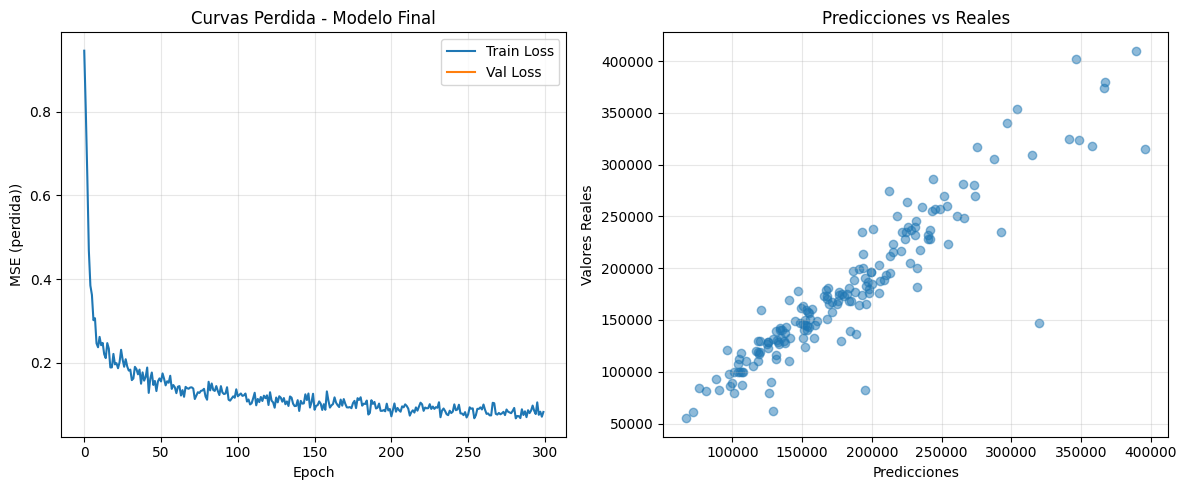

In [ ]:
print("=== ENTRENAMIENTO MODELO FINAL ===")

X_train_full = torch.cat([X_train_tensor, X_val_tensor])
y_train_full = torch.cat([y_train_tensor, y_val_tensor])
train_full_dataset = TensorDataset(X_train_full, y_train_full)
train_full_loader = DataLoader(train_full_dataset, batch_size=best_config['batch_size'], shuffle=True)

#cracion modloe final
final_model = MLP(
    input_dim=X_train_tensor.shape[1],
    hidden_layers=best_config['hidden_layers'],
    activation=best_config['activation'],
    dropout=best_config['dropout']
).to(device)

optimizer = optim.Adam(final_model.parameters(), lr=best_config['lr'], weight_decay=best_config['weight_decay'])
criterion = nn.MSELoss()

final_train_losses, final_val_losses = train_model(
    final_model, train_full_loader, None, optimizer, criterion,
    best_config['epochs'], device, early_stopping_patience=30
)

test_metrics = evaluate_model(final_model, X_test_tensor, y_test_tensor, scaler_y, device)

print("--- RESULTADOS ---")
print(f"  RMSE: {test_metrics['RMSE']:,.2f}")

#graficas perdidas
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(final_train_losses, label='Train Loss')
plt.plot(final_val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE (perdida))')
plt.title('Curvas Perdida - Modelo Final')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(test_metrics['predictions'], scaler_y.inverse_transform(y_test_tensor.numpy()), alpha=0.5)
plt.xlabel('Predicciones')
plt.ylabel('Valores Reales')
plt.title('Predicciones vs Reales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Guardar Modelo

In [ ]:
print("=== GUARDAR MODELO ===")

torch.save(final_model.state_dict(), f'{MODEL_PATH}/modelo_final.pth')

#guardar scalers
joblib.dump(scaler_X, f'{MODEL_PATH}/scaler_X.pkl')
joblib.dump(scaler_y, f'{MODEL_PATH}/scaler_y.pkl')

with open(f'{MODEL_PATH}/feature_names.json', 'w') as f:
    json.dump(feature_names, f)

#mejor config
with open(f'{MODEL_PATH}/mejor_config.json', 'w') as f:
    serializable_config = {
        'hidden_layers': best_config['hidden_layers'],
        'activation': best_config['activation'],
        'lr': best_config['lr'],
        'dropout': best_config['dropout'],
        'weight_decay': best_config['weight_decay'],
        'batch_size': best_config['batch_size'],
        'epochs': best_config['epochs']
    }
    json.dump(serializable_config, f)

#resutlados
results_df.to_csv(f'{MODEL_PATH}/resultados.csv', index=False)

#metricas finales
final_metrics_df = pd.DataFrame([{
    'Modelo': 'Final',
    'RMSE': test_metrics['RMSE'],
    'MAE': test_metrics['MAE'],
    'R2': test_metrics['R2']
}])
final_metrics_df.to_csv(f'{MODEL_PATH}/metricas_finales.csv', index=False)

print("Archivos guardados....")

=== GUARDAR MODELO ===
Archivos guardados....


# COMPETENCIA

In [ ]:
archivo_com = 'test_features-1.csv'

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, activation='relu', dropout=0.0):
        super(MLP, self).__init__()
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))

            if activation == 'relu':
                layers.append(nn.ReLU())
            elif activation == 'leaky_relu':
                layers.append(nn.LeakyReLU(0.1))
            elif activation == 'selu':
                layers.append(nn.SELU())
            elif activation == 'tanh':
                layers.append(nn.Tanh())
            elif activation == 'sigmoid':
                layers.append(nn.Sigmoid())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

#preddciones
def predicciones(archivo_test):
  print("....Cargando....")

  scaler_X = joblib.load(f'{MODEL_PATH}/scaler_X.pkl')
  scaler_y = joblib.load(f'{MODEL_PATH}/scaler_y.pkl')
  print("  Scalers cargados")

  with open(f'{MODEL_PATH}/feature_names.json', 'r') as f:
        feature_names = json.load(f)
  print(f"{len(feature_names)} caracteristicas cargadas")

  with open(f'{MODEL_PATH}/mejor_config.json', 'r') as f:
        config = json.load(f)
  print(f"  Config cargada: {config['hidden_layers']}")

  df_test = pd.read_csv(archivo_test)
  print(f"  Dataset cargado:\n - Filas: {df_test.shape[0]}\n -Columnas: {df_test.shape[1]}")

  if 'Id' not in df_test.columns:
      print("  No hay IDs, se haran secuencialmente")
      ids = pd.Series(range(1, len(df_test) + 1))
  else:
      ids = df_test['Id'].copy()
      print("  IDs encontrados")

  print("Preprocesando datos...")

  df_clean = df_test.copy()

  #nulos
  cat_cols = df_clean.select_dtypes(include=['object']).columns
  for col in cat_cols:
      if df_clean[col].isnull().any():
          df_clean[col] = df_clean[col].fillna('NA')
          print(f"  Nulos transformados en {col}")

  num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
  exclude_cols = ['Id']
  for col in exclude_cols:
      if col in num_cols:
          num_cols = num_cols.drop(col)

  for col in num_cols:
      if df_clean[col].isnull().any():
          df_clean[col] = df_clean[col].fillna(df_clean[col].median())
          print(f"  Nulos transformados en {col}")

  #one hot econding
  cat_cols_final = df_clean.select_dtypes(include=['object']).columns.tolist()
  if cat_cols_final:
      df_clean = pd.get_dummies(df_clean, columns=cat_cols_final, drop_first=True)
      print(f"One-Hot Encoding aplicado")

  columnas_faltantes = []
  for col in feature_names:
      if col not in df_clean.columns:
          df_clean[col] = 0
          columnas_faltantes.append(col)

  if columnas_faltantes:
      print(f"  {len(columnas_faltantes)} columnas agregadas con ceros")

  cols_to_keep = [col for col in df_clean.columns if col in feature_names]
  df_clean = df_clean[cols_to_keep]
  df_clean = df_clean[feature_names]
  print(f"  Dataset alineado, {df_clean.shape[1]} columnas")

  #escalra
  X_test_scaled = scaler_X.transform(df_clean)
  print(f"  Caracteristicas escaladas")

  #carga modelo
  print("Cargando modelo")
  device = 'cuda' if torch.cuda.is_available() else 'cpu'
  print(f"  Dispositivo: {device}")

  model = MLP(
      input_dim=len(feature_names),
      hidden_layers=config['hidden_layers'],
      activation=config['activation'],
      dropout=0.0
  ).to(device)

  model.load_state_dict(torch.load(f'{MODEL_PATH}/modelo_final.pth', map_location=device))
  model.eval()
  print("  Modelo cargado")

  #oredicciones
  print("--- PREDICCIONES ---")

  with torch.no_grad():
      X_tensor = torch.FloatTensor(X_test_scaled).to(device)
      predictions_scaled = model(X_tensor).cpu().numpy()

  predictions = scaler_y.inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()
  predictions = np.round(predictions, 2)

  print("Predicciones generadoas")

  print("Guardando datos")


  output_df = pd.DataFrame({
      'Id': ids,
      'Predictions': predictions
  })

  output_path = f'{MODEL_PATH}/predicciones_competencia.csv'
  output_df.to_csv(output_path, index=False)
  print(f"  Predicciones en: {output_path}")

  print("--- RESULTADOS ---")
  print(f"{print(output_df.head(10).to_string(index=False))}")

  return output_df

predicciones = predicciones(archivo_com)